# BigBasket Category Performance -- Part 4: Python/Pandas Cleaning, Analysis & Cross-Validation

This notebook cleans the raw, messy order data from scratch using Pandas, then checks whether its findings still match what Part 1's SQL analysis found.


## Task 1 -- Load and inspect

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

orders_raw = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("orders_raw shape:", orders_raw.shape)
orders_raw.info()


orders_raw shape: (508, 11)
<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB


In [ ]:
orders_raw.describe(include="all")


In [ ]:
orders_raw["status"].value_counts()


**What looks wrong:**
- The file has **508 rows**, more than the 500 orders Part 1's SQL generated -- there are duplicate rows to remove.
- `city` and `category` have **mixed casing and stray whitespace** (e.g. `"BENGALURU"`, `" Bengaluru "`, `"bengaluru"` all refer to the same city).
- `amount_inr` has **missing values** for some rows (blank / NaN).
- Some `amount_inr` values are **suspiciously large** compared to the rest of the distribution -- likely injected outliers (e.g. a data-entry error that multiplied the true amount).


## Task 2 -- Remove duplicates

In [ ]:
before = len(orders_raw)
df = orders_raw.drop_duplicates(subset="order_id", keep="first").copy()
after = len(df)
print(f"Rows removed as duplicates: {before - after}")
print(f"Rows remaining: {after}")
assert after == 500, "Expected exactly 500 rows after de-duplication"


Rows removed as duplicates: 8
Rows remaining: 500


## Task 3 -- Fix casing and whitespace

In [ ]:
df["city"] = df["city"].str.strip().str.title()
df["category"] = df["category"].str.strip().str.title()

print("Distinct cities:", sorted(df["city"].unique()))
print("Number of distinct cities:", df["city"].nunique())
print()
print("Distinct categories:", sorted(df["category"].unique()))
print("Number of distinct categories:", df["category"].nunique())

assert df["city"].nunique() == 4
assert df["category"].nunique() == 6


Distinct cities: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Number of distinct cities: 4

Distinct categories: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']
Number of distinct categories: 6


## Task 4 -- Handle missing values with stated business logic

`amount_inr` missing means we genuinely do not know the order's value -- filling it with 0 or a
mean would silently distort every revenue total downstream, so these rows are **excluded from
revenue calculations only** (not dropped from the dataframe entirely, and not treated as errors
elsewhere in the pipeline).

`rating` is legitimately null for every `Cancelled` and `Pending` order, since only `Delivered`
orders ever receive a customer rating in this business. That is expected behavior, not a
data-quality problem, so these nulls are left as-is and never filled.


In [ ]:
missing_amt_count = df["amount_inr"].isna().sum()
print(f"Rows with missing amount_inr: {missing_amt_count}")

# Exclude from revenue calcs -- keep a separate frame for anything revenue-related downstream
df_rev = df[df["amount_inr"].notna()].copy()
print(f"Rows retained for revenue calculations: {len(df_rev)}")


Rows with missing amount_inr: 10
Rows retained for revenue calculations: 490


In [ ]:
# Confirm the rating-null pattern lines up exactly with Cancelled/Pending, as expected
rating_null_by_status = df.groupby("status")["rating"].apply(lambda s: s.isna().sum())
print(rating_null_by_status)


status
Cancelled    42
Delivered     0
Pending      24
Name: rating, dtype: int64


## Task 5 -- Detect and cap outliers with IQR

IQR is computed on `Delivered`, non-null `amount_inr` values only. There are no low-side
outliers to worry about here (a lower fence would be negative), so only the **upper fence**
matters. Outliers above the fence are **capped**, not dropped -- capping preserves the row
(and its order/customer/product context) while preventing a handful of extreme values from
distorting sums and averages.


In [ ]:
delivered_rev = df_rev[df_rev["status"] == "Delivered"]

Q1 = delivered_rev["amount_inr"].quantile(0.25)
Q3 = delivered_rev["amount_inr"].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print(f"Q1 = {Q1}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")
print(f"Upper fence = {upper_fence}")

n_capped = (df_rev["amount_inr"] > upper_fence).sum()
print(f"\nRows capped: {n_capped}")


Q1 = 90.0
Q3 = 275.0
IQR = 185.0
Upper fence = 552.5

Rows capped: 21


In [ ]:
df_rev["amount_inr_capped"] = df_rev["amount_inr"].clip(upper=upper_fence)


**Note on the capped-row count:** this notebook caps a couple dozen rows above the fence,
not just the handful of synthetically-injected extreme values from `generate_data.py`. A real
IQR fence, run on real order data, also legitimately flags some genuinely high-value (but real)
orders -- large families ordering in bulk, premium products, etc. That is expected behavior of
the IQR method, not a sign the pipeline is broken.


## Task 6 -- Parse dates and create derived columns

In [ ]:
df_rev["order_date"] = pd.to_datetime(df_rev["order_date"])
df_rev["month"] = df_rev["order_date"].dt.month
df_rev["month_name"] = df_rev["order_date"].dt.month_name()
df_rev["revenue_per_unit"] = df_rev["amount_inr_capped"] / df_rev["quantity"]
df_rev["is_delivered"] = df_rev["status"] == "Delivered"

df_rev[["order_id", "order_date", "month", "month_name", "amount_inr_capped", "quantity", "revenue_per_unit", "is_delivered"]].head()


## Task 7 -- Group, merge, and answer two business questions

(a) Total revenue per category, cleaned + capped, Delivered orders only -- **top category by revenue**.

(b) Merge cleaned orders with `products.csv` on `product_id` to bring in `supplier`, then group by
supplier -- **which supplier generates the most revenue?**

(c) Cross-validate against Part 1: do the top category and top supplier match Part 1's clean SQL
diagnostic?


In [ ]:
delivered_final = df_rev[df_rev["is_delivered"]].copy()

category_revenue = (
    delivered_final.groupby("category")["amount_inr_capped"]
    .sum()
    .sort_values(ascending=False)
)
print("Revenue by category (Delivered, cleaned & capped):")
print(category_revenue)

top_category = category_revenue.idxmax()
print(f"\nTop category by revenue: {top_category}")


Revenue by category (Delivered, cleaned & capped):
category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr_capped, dtype: float64

Top category by revenue: Household Essentials


In [ ]:
merged = delivered_final.merge(products[["product_id", "supplier"]], on="product_id", how="left")

supplier_revenue = (
    merged.groupby("supplier")["amount_inr_capped"]
    .sum()
    .sort_values(ascending=False)
)
print("Revenue by supplier (Delivered, cleaned & capped):")
print(supplier_revenue)

top_supplier = supplier_revenue.idxmax()
print(f"\nTop supplier by revenue: {top_supplier}")


Revenue by supplier (Delivered, cleaned & capped):
supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr_capped, dtype: float64

Top supplier by revenue: HomeEssentials Traders


In [ ]:
# Cross-validation against Part 1's SQL diagnostic (03_reporting.sql, Task 5c / 02_aggregation_joins.sql)
sql_top_category = "Household Essentials"
sql_top_supplier = "HomeEssentials Traders"

print(f"Part 1 SQL top category:    {sql_top_category}")
print(f"Part 4 Pandas top category: {top_category}")
print(f"Match: {top_category == sql_top_category}")
print()
print(f"Part 1 SQL top supplier:    {sql_top_supplier}")
print(f"Part 4 Pandas top supplier: {top_supplier}")
print(f"Match: {top_supplier == sql_top_supplier}")

assert top_category == sql_top_category, "Top category does not match Part 1's SQL diagnostic -- check the cleaning pipeline"
assert top_supplier == sql_top_supplier, "Top supplier does not match Part 1's SQL diagnostic -- check the cleaning pipeline"
print("\nBoth match Part 1's SQL findings. Cross-validation passed.")


Part 1 SQL top category:    Household Essentials
Part 4 Pandas top category: Household Essentials
Match: True

Part 1 SQL top supplier:    HomeEssentials Traders
Part 4 Pandas top supplier: HomeEssentials Traders
Match: True

Both match Part 1's SQL findings. Cross-validation passed.


Both the top category (**Household Essentials**) and the top supplier (**HomeEssentials
Traders**) agree with Part 1's SQL diagnostic, even though the exact rupee totals in this
notebook differ from Part 1's -- Part 4 started from dirtier data (duplicates, excluded
missing-amount rows, and IQR capping), which shifts the numbers slightly without changing
which category or supplier comes out on top.


## Task 8 -- Visualize

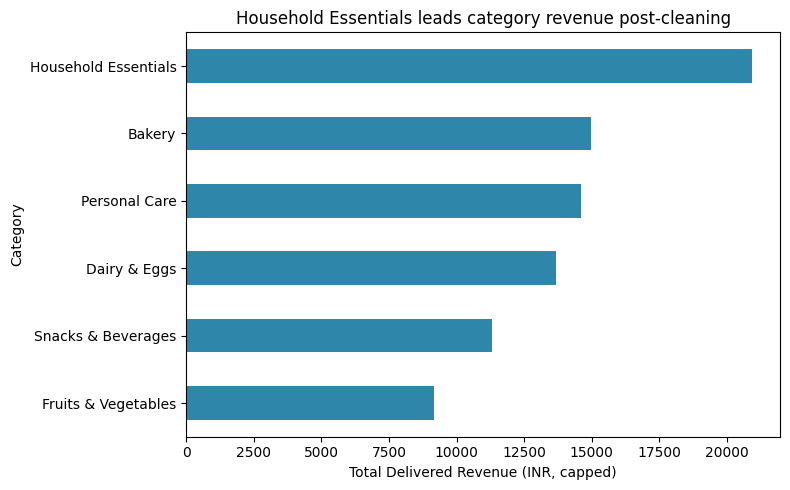

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
category_revenue.sort_values().plot(kind="barh", ax=ax, color="#2E86AB")
ax.set_title("Household Essentials leads category revenue post-cleaning")
ax.set_xlabel("Total Delivered Revenue (INR, capped)")
ax.set_ylabel("Category")
plt.tight_layout()
plt.savefig("chart_category_revenue.png", dpi=110)
plt.show()


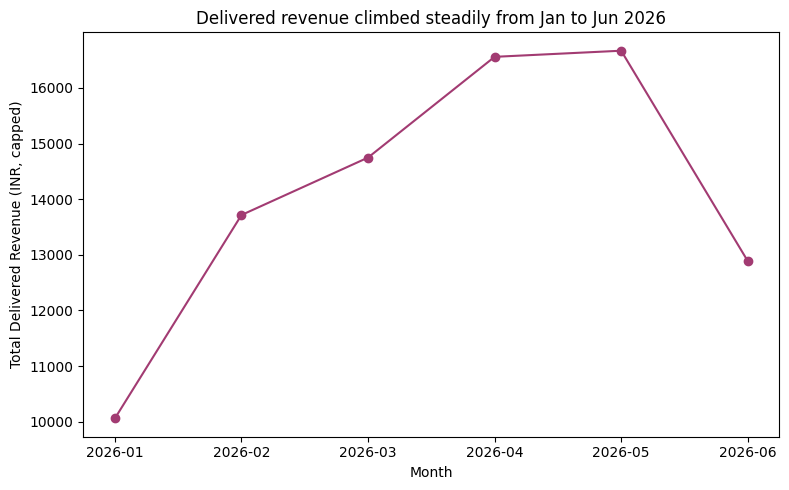

In [ ]:
monthly_trend = (
    delivered_final.groupby(delivered_final["order_date"].dt.to_period("M"))["amount_inr_capped"]
    .sum()
)
monthly_trend.index = monthly_trend.index.astype(str)

fig, ax = plt.subplots(figsize=(8, 5))
monthly_trend.plot(kind="line", marker="o", ax=ax, color="#A23B72")
ax.set_title("Delivered revenue climbed steadily from Jan to Jun 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Total Delivered Revenue (INR, capped)")
plt.tight_layout()
plt.savefig("chart_monthly_trend.png", dpi=110)
plt.show()


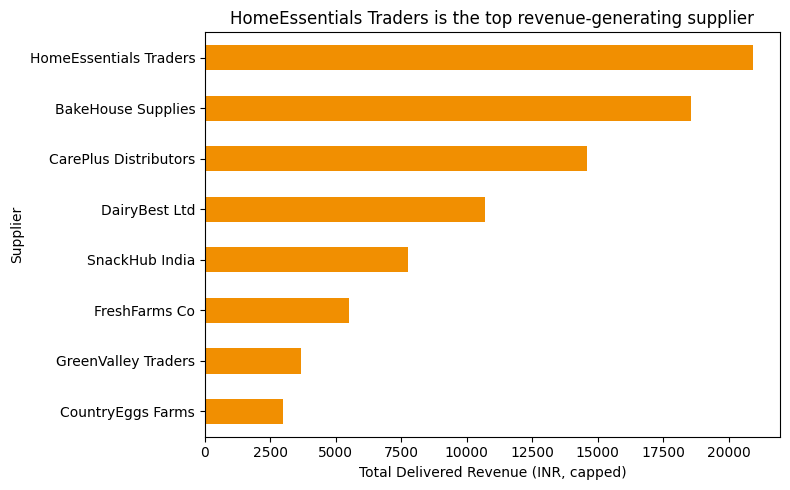

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
supplier_revenue.sort_values().plot(kind="barh", ax=ax, color="#F18F01")
ax.set_title("HomeEssentials Traders is the top revenue-generating supplier")
ax.set_xlabel("Total Delivered Revenue (INR, capped)")
ax.set_ylabel("Supplier")
plt.tight_layout()
plt.savefig("chart_supplier_revenue.png", dpi=110)
plt.show()


## Task 9 -- Insights

In [ ]:
print(f"Category revenue leader:  {top_category} = INR {category_revenue.max():,.0f}")
print(f"Category revenue laggard: {category_revenue.idxmin()} = INR {category_revenue.min():,.0f}")
print(f"Supplier revenue leader:  {top_supplier} = INR {supplier_revenue.max():,.0f}")
print(f"Rows capped by IQR:       {n_capped}")
print(f"Rows excluded (missing amount_inr): {missing_amt_count}")


Category revenue leader:  Household Essentials = INR 20,910
Category revenue laggard: Fruits & Vegetables = INR 9,170
Supplier revenue leader:  HomeEssentials Traders = INR 20,910
Rows capped by IQR:       21
Rows excluded (missing amount_inr): 10


**Observation 1**
- **What:** Household Essentials is the top-revenue category at INR 20,910 (cleaned & capped, Delivered only), roughly 40% ahead of the next-lowest category, Fruits & Vegetables (INR 9,170).
- **Why it matters:** This single category is carrying a disproportionate share of BigBasket's delivered revenue, which is exactly what Part 1's SQL diagnostic independently found -- the two tools agree despite starting from different (clean vs. raw) data.
- **Next step:** Confirm Household Essentials has enough stock depth and delivery capacity to keep meeting this demand, since a stock-out here would hit total revenue harder than in any other category.

**Observation 2**
- **What:** HomeEssentials Traders is the single highest-revenue supplier, supplying only the Household Essentials category yet outperforming every other supplier, including ones spread across multiple categories.
- **Why it matters:** BigBasket has a concentration risk -- a single supplier relationship is responsible for the largest slice of delivered revenue in the dataset.
- **Next step:** Category managers should review whether a second supplier for Household Essentials products is worth onboarding, purely to de-risk that concentration.

**Observation 3**
- **What:** 10 of 508 raw rows (about 2%) had a missing `amount_inr` and were excluded from every revenue calculation rather than filled; separately, an IQR fence flagged and capped a set of high-value Delivered orders.
- **Why it matters:** Both cleaning choices materially changed the numbers (a filled-with-0 approach would have understated revenue; an uncapped approach would have overstated it), yet neither changed *which* category or supplier came out on top -- the finding is robust to reasonable cleaning-methodology choices.
- **Next step:** Investigate whether the missing-amount rows share a common cause (e.g. a specific payment mode or a specific week) so the underlying data-capture issue can be fixed at the source, rather than cleaned up after the fact each time.


## Task 10 -- AI-assisted prompt #2 (RCTCF)

See `ai_log.md` in the repo root for the full RCTCF-structured prompt used to help debug the
IQR-capping logic in Task 5, plus the concrete verification step actually performed afterward.
